In [2]:
from statsbombpy import sb
import pandas as pd
from mplsoccer import Pitch, Sbopen
import matplotlib.pyplot as plt
comps = sb.competitions()
# comps["competition_name"].unique()
comps[comps["competition_name"]=="FIFA World Cup"]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
30,43,3,International,FIFA World Cup,male,False,True,2018,2024-06-12T07:38:19.345758,2021-06-13T16:17:31.694,None,2024-06-12T07:38:19.345758
31,43,55,International,FIFA World Cup,male,False,True,1990,2023-06-28T10:58:20.137929,2021-06-12T16:17:31.694,None,2023-06-28T10:58:20.137929
32,43,54,International,FIFA World Cup,male,False,True,1986,2023-12-26T22:34:04.263530,2021-06-13T16:17:31.694,None,2023-12-26T22:34:04.263530
33,43,51,International,FIFA World Cup,male,False,True,1974,2024-02-13T02:52:29.582599,2021-06-13T16:17:31.694,None,2024-02-13T02:52:29.582599
34,43,272,International,FIFA World Cup,male,False,True,1970,2024-02-13T14:23:06.735299,None,None,2024-02-13T14:23:06.735299
35,43,270,International,FIFA World Cup,male,False,True,1962,2023-06-26T10:38:00.323984,None,None,2023-06-26T10:38:00.323984
36,43,269,International,FIFA World Cup,male,False,True,1958,2024-02-13T14:22:08.222297,None,None,2024-02-13T14:22:08.222297


In [3]:
matches=sb.matches(competition_id=43,season_id=106)
matches[matches['home_team']=='Belgium']

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
32,3857283,2022-11-27,15:00:00.000,0,2,available,available,2023-02-28T21:26:37.636261,2023-06-21T18:29:02.259940,2,...,Spain,1000518,Walid Regragui,None,1975-09-23,154,Morocco,1.1.0,2,2
58,3857268,2022-11-23,21:00:00.000,1,0,available,available,2023-08-12T16:44:27.619465,2023-08-12T16:48:09.197442,1,...,Spain,4435,John Herdman,None,1975-07-19,68,England,1.1.0,2,2


In [4]:
events = sb.events(match_id=3857283)
parser = Sbopen()
df, related, freeze, tactics = parser.event(3857283)
df.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'under_pressure',
       'outcome_id', 'outcome_name', 'ball_recovery_recovery_failure',
       'counterpress', 'pass_cross', 'off_camera', 'out',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'technique_id', 'technique_name',
       'shot_first_time', 'goalkeeper_position_id', 'goalkeeper_position_name',
       'pass_switch', 'aerial_won', 'dribble_overrun',
   

In [5]:
df = df[df['team_name']=="Belgium"]
df['type_name'].unique()

array(['Starting XI', 'Half Start', 'Pass', 'Ball Receipt', 'Carry',
       'Ball Recovery', 'Dispossessed', 'Pressure', 'Dribbled Past',
       'Foul Won', 'Dribble', 'Miscontrol', 'Injury Stoppage',
       'Clearance', 'Duel', 'Shot', 'Shield', 'Block', '50/50',
       'Foul Committed', 'Interception', 'Goal Keeper', 'Offside',
       'Half End', 'Substitution', 'Tactical Shift'], dtype=object)

In [6]:
passes = df[df['type_name']=='Pass']
passes.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'under_pressure',
       'outcome_id', 'outcome_name', 'ball_recovery_recovery_failure',
       'counterpress', 'pass_cross', 'off_camera', 'out',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'technique_id', 'technique_name',
       'shot_first_time', 'goalkeeper_position_id', 'goalkeeper_position_name',
       'pass_switch', 'aerial_won', 'dribble_overrun',
   

In [7]:
passes = passes[['id','minute','player_id','player_name','x','y','end_x', 'end_y','pass_recipient_id','pass_recipient_name','outcome_id','outcome_name']]

In [8]:
successful=passes[passes['outcome_name'].isnull()]

In [9]:
successful = successful[successful['minute']>45]
successful

,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name
1847,ec2e22e7-9844-437a-8e18-8747df6a761d,46,3077.0,Jan Vertonghen,48.8,60.5,66.8,78.0,3089.0,Kevin De Bruyne,NaN,NaN
1868,55403b58-b42b-46e4-b804-837649c0e9a9,46,5642.0,Axel Witsel,63.1,5.3,47.1,5.9,6989.0,Timothy Castagne,NaN,NaN
1872,b273eb59-eeb9-4ec4-821a-019b911cec2f,47,6989.0,Timothy Castagne,47.3,6.2,56.3,26.9,48347.0,Amadou Onana,NaN,NaN
1905,02865188-302a-4926-aa40-12916223b2c5,47,3089.0,Kevin De Bruyne,19.4,26.7,34.4,26.7,3621.0,Eden Hazard,NaN,NaN
1910,72d56d94-36af-4f9d-81c3-f16129b5b830,47,3621.0,Eden Hazard,33.9,27.8,27.8,12.2,5632.0,Thorgan Hazard,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3574,3e3150d4-53a3-4b4b-a29d-594fd53aacb6,93,3077.0,Jan Vertonghen,56.7,19.2,56.7,48.1,20005.0,Toby Alderweireld,NaN,NaN
3577,b3c97635-384d-4517-926a-46bfeba1658c,93,20005.0,Toby Alderweireld,56.9,47.9,66.6,63.3,3089.0,Kevin De Bruyne,NaN,NaN
3595,a350d989-6f1e-47d5-961c-2ccaecc8f355,94,3509.0,Thibaut Courtois,15.2,37.0,29.6,34.8,5642.0,Axel Witsel,NaN,NaN
3611,4a319215-fdb9-4a51-947b-719813a19a96,94,5642.0,Axel Witsel,19.7,9.6,27.2,10.0,3077.0,Jan Vertonghen,NaN,NaN


In [10]:
df_lineup = parser.lineup(3857283)
jersey_data=df_lineup[['player_id','jersey_number']]
jersey_data

,player_id,jersey_number
0,2954,8
1,3077,5
2,3089,7
3,3176,15
4,3289,9
5,3457,23
6,3509,1
7,3539,12
8,3621,10
9,5630,14


In [11]:
successful= pd.merge(successful,jersey_data,on='player_id')
successful.rename(columns={'jersey_number':'passer'},inplace=True)
successful

,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name,passer
0,ec2e22e7-9844-437a-8e18-8747df6a761d,46,3077.0,Jan Vertonghen,48.8,60.5,66.8,78.0,3089.0,Kevin De Bruyne,NaN,NaN,5
1,55403b58-b42b-46e4-b804-837649c0e9a9,46,5642.0,Axel Witsel,63.1,5.3,47.1,5.9,6989.0,Timothy Castagne,NaN,NaN,6
2,b273eb59-eeb9-4ec4-821a-019b911cec2f,47,6989.0,Timothy Castagne,47.3,6.2,56.3,26.9,48347.0,Amadou Onana,NaN,NaN,21
3,02865188-302a-4926-aa40-12916223b2c5,47,3089.0,Kevin De Bruyne,19.4,26.7,34.4,26.7,3621.0,Eden Hazard,NaN,NaN,7
4,72d56d94-36af-4f9d-81c3-f16129b5b830,47,3621.0,Eden Hazard,33.9,27.8,27.8,12.2,5632.0,Thorgan Hazard,NaN,NaN,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,3e3150d4-53a3-4b4b-a29d-594fd53aacb6,93,3077.0,Jan Vertonghen,56.7,19.2,56.7,48.1,20005.0,Toby Alderweireld,NaN,NaN,5
281,b3c97635-384d-4517-926a-46bfeba1658c,93,20005.0,Toby Alderweireld,56.9,47.9,66.6,63.3,3089.0,Kevin De Bruyne,NaN,NaN,2
282,a350d989-6f1e-47d5-961c-2ccaecc8f355,94,3509.0,Thibaut Courtois,15.2,37.0,29.6,34.8,5642.0,Axel Witsel,NaN,NaN,1
283,4a319215-fdb9-4a51-947b-719813a19a96,94,5642.0,Axel Witsel,19.7,9.6,27.2,10.0,3077.0,Jan Vertonghen,NaN,NaN,6


In [12]:
jersey_data.rename(columns={'player_id':'pass_recipient_id'},inplace=True)
successful = pd.merge(successful,jersey_data, on='pass_recipient_id')
successful.rename(columns={'jersey_number':'recipient'},inplace=True)
successful

C:\Users\HP\AppData\Local\Temp\ipykernel_14288\1718113474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jersey_data.rename(columns={'player_id':'pass_recipient_id'},inplace=True)


,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name,passer,recipient
0,ec2e22e7-9844-437a-8e18-8747df6a761d,46,3077.0,Jan Vertonghen,48.8,60.5,66.8,78.0,3089.0,Kevin De Bruyne,NaN,NaN,5,7
1,55403b58-b42b-46e4-b804-837649c0e9a9,46,5642.0,Axel Witsel,63.1,5.3,47.1,5.9,6989.0,Timothy Castagne,NaN,NaN,6,21
2,b273eb59-eeb9-4ec4-821a-019b911cec2f,47,6989.0,Timothy Castagne,47.3,6.2,56.3,26.9,48347.0,Amadou Onana,NaN,NaN,21,18
3,02865188-302a-4926-aa40-12916223b2c5,47,3089.0,Kevin De Bruyne,19.4,26.7,34.4,26.7,3621.0,Eden Hazard,NaN,NaN,7,10
4,72d56d94-36af-4f9d-81c3-f16129b5b830,47,3621.0,Eden Hazard,33.9,27.8,27.8,12.2,5632.0,Thorgan Hazard,NaN,NaN,10,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,3e3150d4-53a3-4b4b-a29d-594fd53aacb6,93,3077.0,Jan Vertonghen,56.7,19.2,56.7,48.1,20005.0,Toby Alderweireld,NaN,NaN,5,2
281,b3c97635-384d-4517-926a-46bfeba1658c,93,20005.0,Toby Alderweireld,56.9,47.9,66.6,63.3,3089.0,Kevin De Bruyne,NaN,NaN,2,7
282,a350d989-6f1e-47d5-961c-2ccaecc8f355,94,3509.0,Thibaut Courtois,15.2,37.0,29.6,34.8,5642.0,Axel Witsel,NaN,NaN,1,6
283,4a319215-fdb9-4a51-947b-719813a19a96,94,5642.0,Axel Witsel,19.7,9.6,27.2,10.0,3077.0,Jan Vertonghen,NaN,NaN,6,5


In [13]:
average_locations= successful.groupby('passer').agg({'x':['mean'],'y':['mean','count']})
average_locations.columns = ['x','y','count']
average_locations

,x,y,count
passer,,,
1,7.938889,42.388889,18
2,50.897222,59.288889,36
5,46.497143,30.297143,35
6,52.939024,32.129268,41
7,73.225806,43.341935,31
8,57.462963,38.396296,27
9,61.000000,40.100000,1
10,63.900000,29.600000,7
14,77.300000,32.481818,11


In [14]:
pass_between = successful.groupby(['passer','recipient']).id.count().reset_index()
pass_between.rename({'id':'pass_count'},axis='columns',inplace=True)
pass_between

,passer,recipient,pass_count
0,1,2,6
1,1,5,6
2,1,6,1
3,1,7,1
4,1,8,1
...,...,...,...
103,21,18,6
104,21,23,1
105,22,7,2
106,22,8,1


In [15]:
pass_between= pd.merge(pass_between, average_locations, on='passer')
pass_between

,passer,recipient,pass_count,x,y,count
0,1,2,6,7.938889,42.388889,18
1,1,5,6,7.938889,42.388889,18
2,1,6,1,7.938889,42.388889,18
3,1,7,1,7.938889,42.388889,18
4,1,8,1,7.938889,42.388889,18
...,...,...,...,...,...,...
103,21,18,6,45.983333,21.226667,30
104,21,23,1,45.983333,21.226667,30
105,22,7,2,36.566667,64.766667,3
106,22,8,1,36.566667,64.766667,3


In [16]:
average_locations=average_locations.rename_axis('recipient')
pass_between= pd.merge(pass_between, average_locations, on='recipient',suffixes=['','_end'])
pass_between

,passer,recipient,pass_count,x,y,count,x_end,y_end,count_end
0,1,2,6,7.938889,42.388889,18,50.897222,59.288889,36
1,1,5,6,7.938889,42.388889,18,46.497143,30.297143,35
2,1,6,1,7.938889,42.388889,18,52.939024,32.129268,41
3,1,7,1,7.938889,42.388889,18,73.225806,43.341935,31
4,1,8,1,7.938889,42.388889,18,57.462963,38.396296,27
...,...,...,...,...,...,...,...,...,...
103,21,18,6,45.983333,21.226667,30,51.109091,41.463636,11
104,21,23,1,45.983333,21.226667,30,53.866667,34.833333,3
105,22,7,2,36.566667,64.766667,3,73.225806,43.341935,31
106,22,8,1,36.566667,64.766667,3,57.462963,38.396296,27


In [17]:
pass_between =pass_between[pass_between['pass_count']>3]
pass_between.drop_duplicates()
pass_between

,passer,recipient,pass_count,x,y,count,x_end,y_end,count_end
0,1,2,6,7.938889,42.388889,18,50.897222,59.288889,36
1,1,5,6,7.938889,42.388889,18,46.497143,30.297143,35
8,2,5,9,50.897222,59.288889,36,46.497143,30.297143,35
9,2,6,6,50.897222,59.288889,36,52.939024,32.129268,41
10,2,7,4,50.897222,59.288889,36,73.225806,43.341935,31
12,2,15,4,50.897222,59.288889,36,46.800000,72.770000,10
14,2,21,4,50.897222,59.288889,36,45.983333,21.226667,30
17,5,2,8,46.497143,30.297143,35,50.897222,59.288889,36
20,5,8,5,46.497143,30.297143,35,57.462963,38.396296,27
25,5,21,7,46.497143,30.297143,35,45.983333,21.226667,30


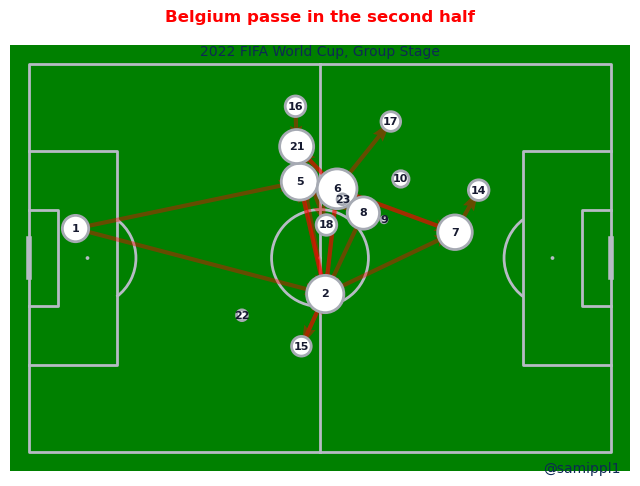

In [18]:
pitch = Pitch(pitch_color='green', line_color='#B6BBC4')
# Set the figure size
fig, ax = pitch.draw(figsize=(8, 6), constrained_layout=True, tight_layout=False)

# Set the face color of the figure
fig.set_facecolor('#FFFFFF')

# Draw arrows and nodes
arrows = pitch.arrows(1.2 * pass_between.x, 0.8 * pass_between.y, 1.2 * pass_between.x_end, 0.8 * pass_between.y_end, ax=ax,color='red', alpha=0.4,width=3)
# arrows = pass_between.apply(create_arrow, axis=1)
# for arrow in arrows:
#     ax.add_patch(arrow)
                 
nodes = pitch.scatter(1.2 * average_locations.x, 0.8 * average_locations.y, s=20*average_locations['count'].values, color='white', edgecolors='#a6aab3', linewidth=2, alpha=1, zorder=1, ax=ax)

                 
# Annotate average_locations
for index, row in average_locations.iterrows():
    pitch.annotate(index, xy=(1.2 * row.x, 0.8 * row.y), c='#161A30',fontweight='bold', va='center', ha='center', size=8, ax=ax)

# Add the endnote
ax.text(114, 85, '@samippl1', color='#0E2954', va='bottom', ha='center', fontsize=10)

# Add the title
ax.set_title('Belgium passe in the second half', color='red', va='center', ha='center', fontsize=12,fontweight='bold',pad=20,loc='center')
ax.annotate('2022 FIFA World Cup, Group Stage', xy=(0.5, 1), xytext=(0, 0),
             xycoords='axes fraction', textcoords='offset points',
             fontsize=10, color='#0E2954', va='top', ha='center')


plt.show()